# Day 12 - Model Improvement and Comparison

**AI & Machine Learning Internship**

**Author:** Neethu Suresh

## Topics Covered

- Feature Selection
- Multiple Machine Learning Models
- Model Comparison
- Performance Evaluation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("student_scores.csv")

df

,Name,Hours_Studied,Attendance,Previous_Score,Final_Score
0,Anu,2,80.0,65.0,68
1,Rahul,5,92.0,78.0,84
2,Sneha,4,88.0,75.0,80
3,Arjun,6,95.0,82.0,90
4,Meera,3,NaN,70.0,74
5,Akhil,7,90.0,88.0,94
6,Diya,5,85.0,NaN,82
7,Rohan,8,98.0,91.0,96
8,Aisha,2,76.0,60.0,65
9,Vivek,4,89.0,77.0,81


In [3]:
df["Attendance"] = df["Attendance"].fillna(df["Attendance"].mean())

df["Previous_Score"] = df["Previous_Score"].fillna(
    df["Previous_Score"].mean()
)

df

,Name,Hours_Studied,Attendance,Previous_Score,Final_Score
0,Anu,2,80.000000,65.000000,68
1,Rahul,5,92.000000,78.000000,84
2,Sneha,4,88.000000,75.000000,80
3,Arjun,6,95.000000,82.000000,90
4,Meera,3,88.111111,70.000000,74
5,Akhil,7,90.000000,88.000000,94
6,Diya,5,85.000000,76.222222,82
7,Rohan,8,98.000000,91.000000,96
8,Aisha,2,76.000000,60.000000,65
9,Vivek,4,89.000000,77.000000,81


In [4]:
X = df[
    [
        "Hours_Studied",
        "Attendance",
        "Previous_Score"
    ]
]

y = df["Final_Score"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_prediction = linear_model.predict(X_test)

In [7]:
tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)

tree_prediction = tree_model.predict(X_test)

In [8]:
linear_r2 = r2_score(
    y_test,
    linear_prediction
)

tree_r2 = r2_score(
    y_test,
    tree_prediction
)


results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree"
    ],
    "R2 Score": [
        linear_r2,
        tree_r2
    ]
})


results

,Model,R2 Score
0,Linear Regression,0.998987
1,Decision Tree,0.750693


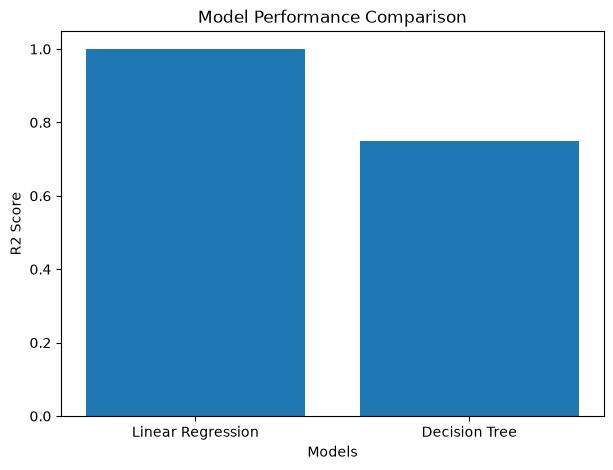

In [9]:
plt.figure(figsize=(7,5))

plt.bar(
    results["Model"],
    results["R2 Score"]
)

plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("R2 Score")

plt.show()

In [10]:
best_model = (
    "Linear Regression"
    if linear_r2 > tree_r2
    else "Decision Tree"
)

print(
    "Best Performing Model:",
    best_model
)

Best Performing Model: Linear Regression


## Conclusion

Comparing different machine learning algorithms helps identify the model that performs better for a specific dataset. Model selection is an important step before deployment.